In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
%load_ext autoreload
%autoreload 2 

#pour pas avoir à reload à chaque fois qu'on mofifie une fonction dans un autre fichier

Fonction preprocess pour 
- charger les données avec le nombre de n_rows et de features à définir
- split test et train
- % valeurs manquantes et drop lignes avec que des valeurs manquantes
- imputation 

In [3]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_9 = preprocess_pipeline(
    sample_size=10000,
    missing_threshold=50,
    features=mes_features
)

print(preprocess_9["X_train"].shape)
preprocess_9["X_train"].head()


d:\Code_data\DESU_ROCHET\test\preprocess.py:26: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, encoding=encoding, nrows=sample_size, quoting=csv.QUOTE_NONE)


(464, 7)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g
8431,348.40,0.40,9.00,0.160,2.30,2.50,12.00
2158,563.70,2.40,7.00,0.508,2.20,5.90,17.60
3164,2450.00,25.00,26.00,0.010,10.00,45.00,31.00
8276,1506.20,0.10,0.50,1.000,8.70,0.50,74.20
1113,445.66,3.39,1.64,0.300,2.27,5.64,11.67


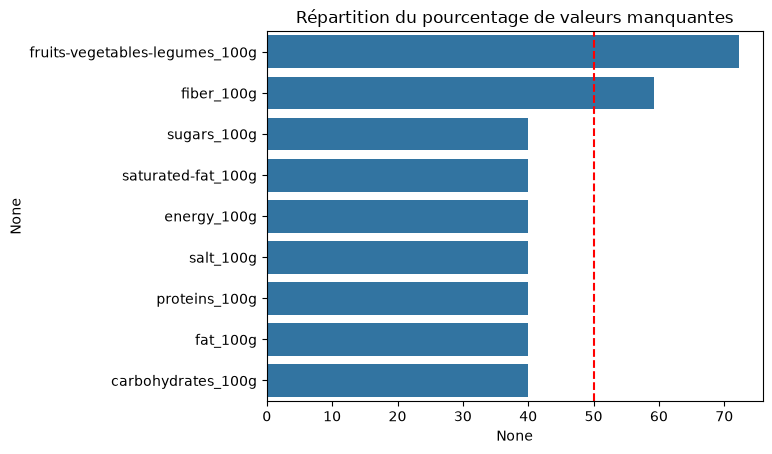

In [4]:
# affiche le graph du % des valeurs manquantes avec seuil 

percent_missing_9 = preprocess_9["percent_missing"]
filtered = percent_missing_9[percent_missing_9.values > 0]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}") 



In [5]:
##vérifie qu'après "drop_rows_all_missing" on a des Nan ou pas à imputer.
## résultat = 1 valeur manquante dans saturated-fat et dans sugars 

from preprocess import load_data, split_known_unknown, split_train_test, compute_missing_percentage, get_columns_to_drop, apply_column_drop, drop_rows_all_missing

df = load_data(sample_size=10000)
df_connu, df_inconnu = split_known_unknown(df, target_col="nutriscore_grade")
X_train, X_test, y_train, y_test = split_train_test(df_connu, mes_features)

percent_missing = compute_missing_percentage(X_train)
columns_to_drop = get_columns_to_drop(percent_missing, threshold=50) 

X_train_avant_imputation = apply_column_drop(X_train, columns_to_drop)
X_train_avant_imputation = drop_rows_all_missing(X_train_avant_imputation)

print(X_train_avant_imputation.isna().sum())

energy_100g           0
saturated-fat_100g    1
sugars_100g           1
salt_100g             0
proteins_100g         0
fat_100g              0
carbohydrates_100g    0
dtype: int64


d:\Code_data\DESU_ROCHET\test\preprocess.py:26: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=sep, encoding=encoding, nrows=sample_size, quoting=csv.QUOTE_NONE)


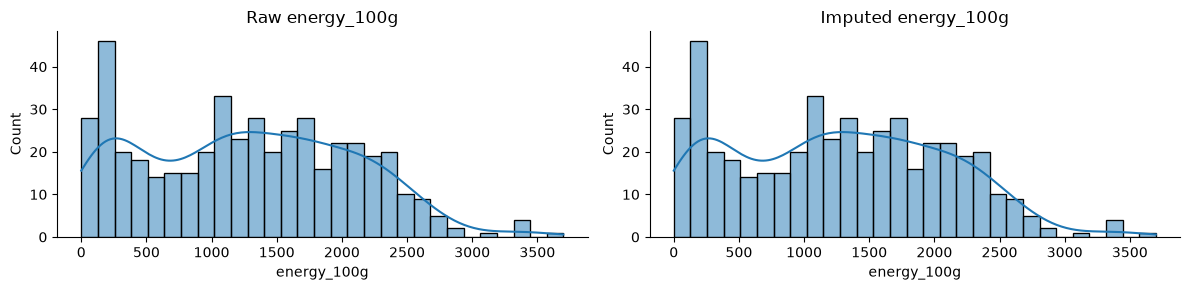

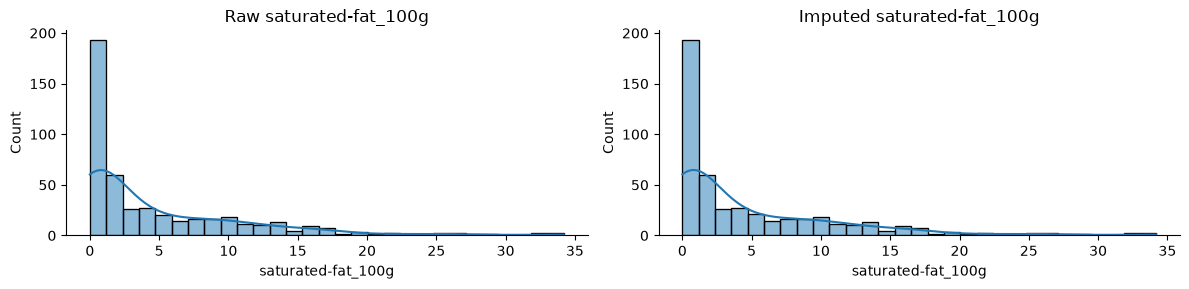

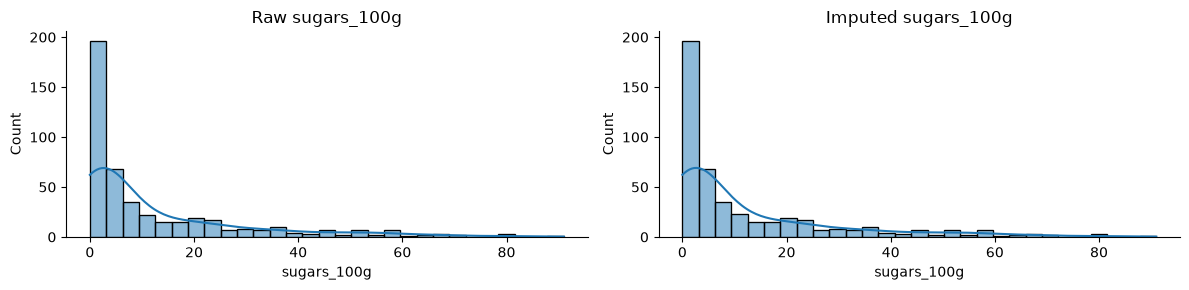

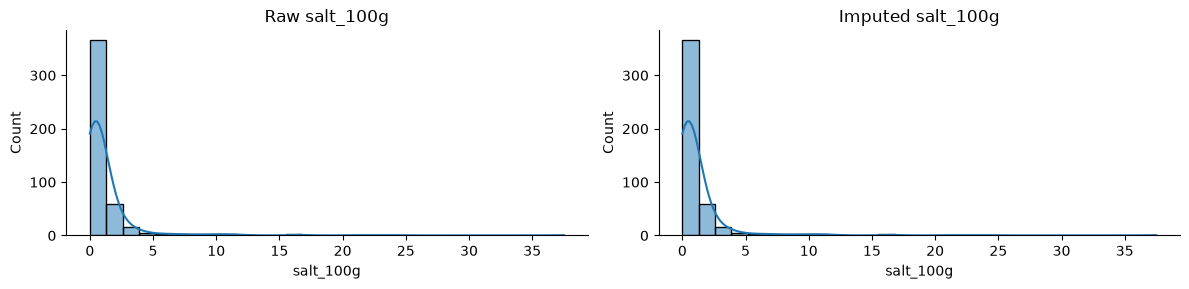

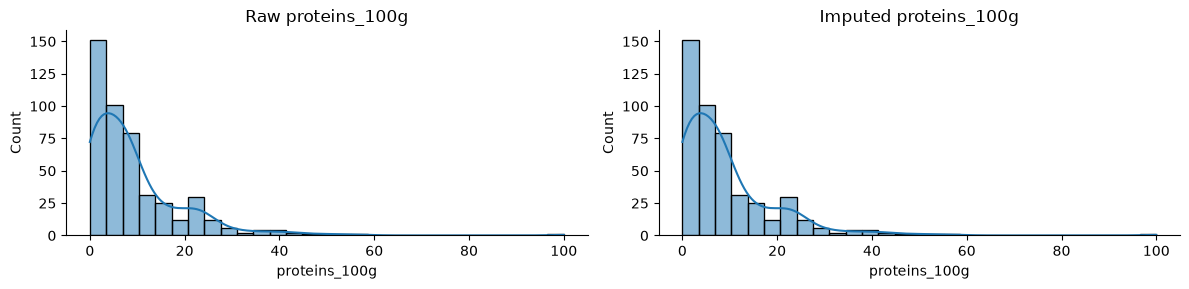

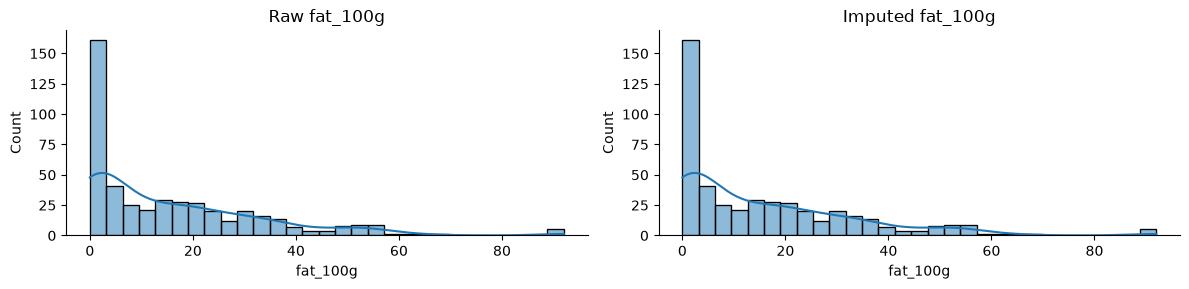

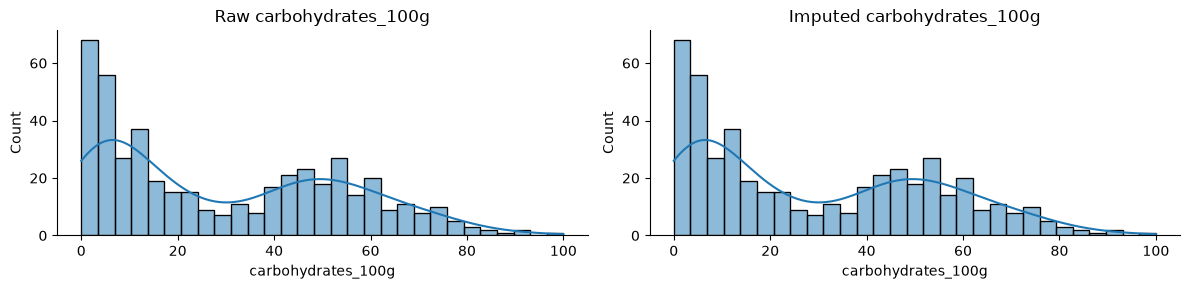

In [6]:
# Comparer avant/après imputation pour voir si les valeurs imputées sont cohérentes avec le reste de la colonne.

X_train_imputed = preprocess_9["X_train"]
features_restantes = list(X_train_imputed.columns)  # colonnes qui ont survécu au drop

def compare_dist(feature, raw_df, imputed_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    # Bins communs calculés sur la plage combinée des deux distributions
    combined_min = min(raw_df[feature].min(), imputed_df[feature].min())
    combined_max = max(raw_df[feature].max(), imputed_df[feature].max())
    bins = np.linspace(combined_min, combined_max, 30)

    ax = axes[0]
    sns.histplot(raw_df.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Raw {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1]
    sns.histplot(imputed_df.loc[:, feature], kde=True, ax=ax, bins=bins)
    ax.set_title(f"Imputed {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

for feature in features_restantes:
    compare_dist(feature, X_train_avant_imputation, X_train_imputed)


Même pipeline mais sur TOUT le fichier (pas juste sample_size lignes), lu par morceaux (chunksize) pour ne pas tout charger en mémoire d'un coup (prend 8mn sur mon ordi(juliette))

In [9]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,   # lit le csv 100 000 lignes à la fois au lieu de tout d'un coup
    missing_threshold=50,
    features=mes_features
)

print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

(758485, 7)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g
716939,1855.6,5.1,27.2,0.8000,5.8,22.4,54.6
576959,272.0,0.0,16.0,0.0000,0.0,0.0,16.0
416885,1705.9,1.6,3.1,1.0825,12.0,5.9,74.0
1186649,2936.0,6.8,3.1,0.0100,14.3,68.1,5.1
260278,1024.7,7.7,6.1,1.4000,15.0,18.0,6.1


In [15]:
# Nombre de lignes "connu" = train + test (après split, donc après pipeline)
nb_connu = len(preprocess_full["y_train"]) + len(preprocess_full["y_test"])
print("Nombre de lignes connu (train+test) :", nb_connu)

# Nombre de lignes "inconnu" (après nettoyage dans la pipeline)
nb_inconnu = len(preprocess_full["X_inconnu"])
print("Nombre de lignes inconnu :", nb_inconnu)

# Total
print("Total :", nb_connu + nb_inconnu)

# Répartition connu/inconnu en %
total = nb_connu + nb_inconnu
print(f"Connu : {nb_connu} ({nb_connu/total*100:.1f}%)")
print(f"Inconnu : {nb_inconnu} ({nb_inconnu/total*100:.1f}%)")

Nombre de lignes connu (train+test) : 1033818
Nombre de lignes inconnu : 1320742
Total : 2354560
Connu : 1033818 (43.9%)
Inconnu : 1320742 (56.1%)


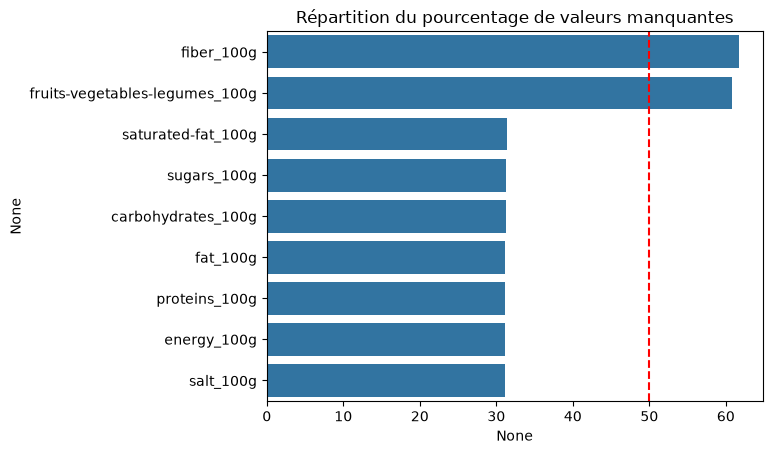

In [8]:
percent_missing_full = preprocess_full["percent_missing"]
filtered = percent_missing_full[percent_missing_full.values > 0]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes");

threshold = 50

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [10]:
X_train = preprocess_full["X_train"]
X_test  = preprocess_full["X_test"]
y_train = preprocess_full["y_train"]
y_test  = preprocess_full["y_test"]
X_inconnu = preprocess_full["X_inconnu"]

On compare différents modèle, on prend celui à la meilleure accuracy et on prédit le nutriscore sur les lignes avec un nutriscore inconnu

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modeles = {
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

resultats = {}
modeles_entraines = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    acc = accuracy_score(y_test, modele.predict(X_test))
    resultats[nom] = acc
    modeles_entraines[nom] = modele
    print(f"{nom}: accuracy = {acc:.3f}")

# Sélection automatique du meilleur modèle (celui avec la meilleure accuracy sur X_test)
meilleur_nom = max(resultats, key=resultats.get)
meilleur_modele = modeles_entraines[meilleur_nom]
print(f"\nMeilleur modèle : {meilleur_nom} (accuracy = {resultats[meilleur_nom]:.3f})")

# Application du meilleur modèle sur les lignes inconnues
predictions_inconnu = meilleur_modele.predict(X_inconnu)

# Optionnel : recoller les prédictions au df_inconnu original pour les consulter
import pandas as pd
resultat_final = X_inconnu.copy()
resultat_final["nutriscore_predit"] = predictions_inconnu
resultat_final.head()

RandomForest: accuracy = 0.653


d:\Code_data\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression: accuracy = 0.283
GradientBoosting: accuracy = 0.587

Meilleur modèle : RandomForest (accuracy = 0.653)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_predit
604,9.00,3.600000,4.900000,1.795091,17.500000,10.20000,22.500000,d
605,856.00,3.400000,1.900000,0.700000,5.900000,12.10000,18.100000,c
606,2770.00,16.129032,3.225806,0.524194,19.677419,54.83871,19.354839,d
712,2221.96,19.300000,37.720000,0.270000,5.680000,30.28000,59.120000,e
744,1982.00,11.000000,65.000000,0.120000,5.700000,19.00000,69.000000,e


In [14]:
print("Nombre de lignes prédites :", resultat_final.shape[0])
resultat_final.sample(20, random_state=42)


Nombre de lignes prédites : 1320742


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g,nutriscore_predit
2627853,3389.200000,13.600000,0.000000,0.000000,0.000000,91.600000,0.000000,b
1618818,1493.100000,0.200000,3.000000,1.795091,12.000000,1.300000,73.000000,d
2451693,1301.000000,5.510514,13228.603518,1.795091,0.400000,15.020009,75.000000,e
630048,417.000000,0.800000,0.000000,2.300000,16.000000,3.000000,2.000000,d
174941,220.000000,0.000000,3.529412,1.795091,2.352941,0.000000,10.588235,c
731339,2325.000000,5.357143,0.000000,0.223214,3.571429,28.571429,64.285714,d
2455235,92.384615,0.000000,2.615385,0.065385,0.923077,0.000000,4.076923,a
1415438,1429.700000,2.800000,0.500000,1.000000,8.700000,34.000000,1.400000,c
1297728,536.600000,6.200000,0.800000,0.570000,6.000000,10.000000,3.800000,c
2940988,211.100000,0.100000,3.700000,0.100000,8.500000,0.100000,3.700000,a


In [ ]:
##OUTLIERS 

from preprocess import preprocess_pipeline

preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,
    missing_threshold=50,
    features=mes_features,
    remove_outliers=True,
    # pas de outlier_exclude -> toutes les colonnes sont filtrées, energy_100g compris
)

print(preprocess_full["X_train"].shape)
print(preprocess_full["outlier_bounds"]["energy_100g"])

print("Outliers dans train :", masque_train.sum())
print("Outliers dans test :", masque_test.sum())

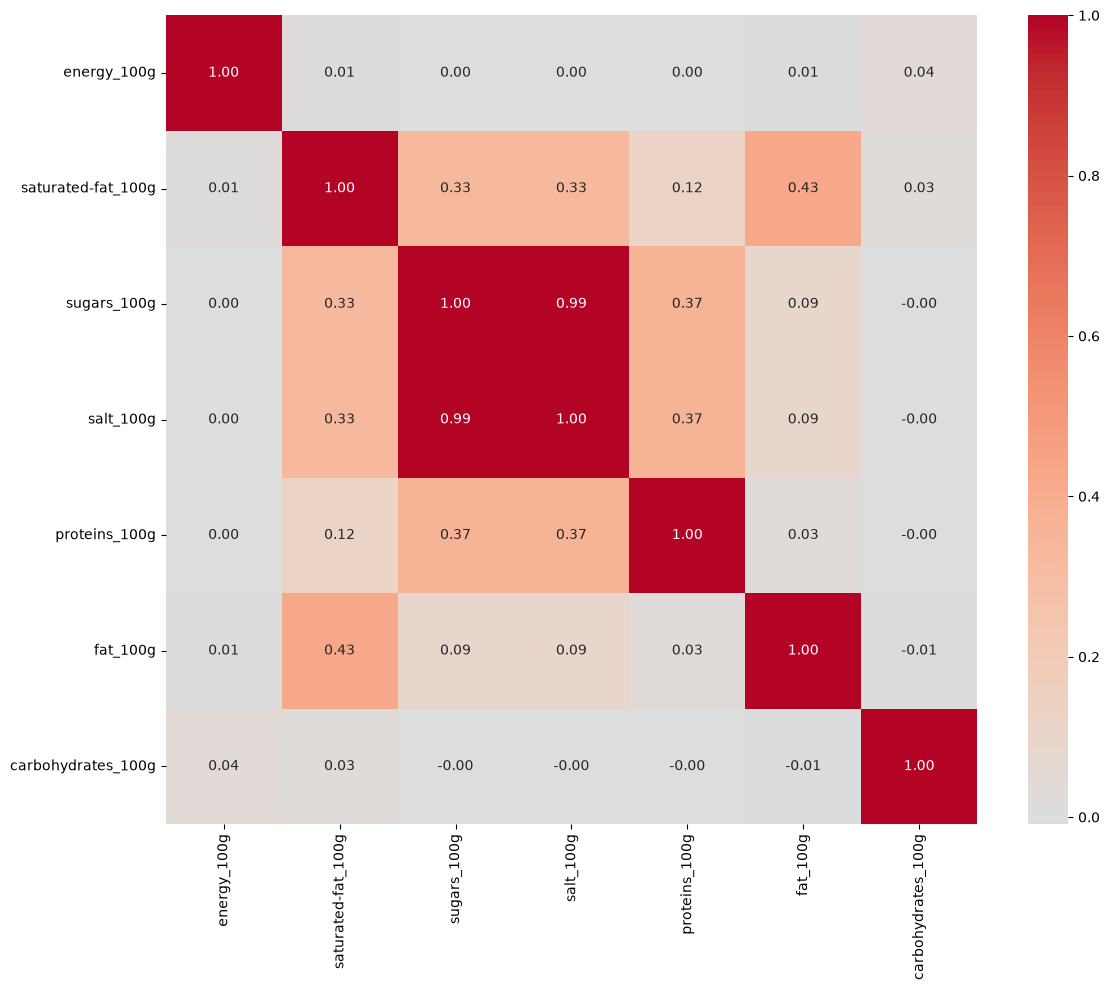

             variable        VIF
0         energy_100g   1.001535
1  saturated-fat_100g   1.368443
2         sugars_100g  67.594544
3           salt_100g  67.500131
4       proteins_100g   1.156871
5            fat_100g   1.229795
6  carbohydrates_100g   1.002535

Variables gardées (VIF < 5.0) : ['energy_100g', 'saturated-fat_100g', 'proteins_100g', 'fat_100g', 'carbohydrates_100g']
Optimization terminated successfully.
         Current function value: 1.176276
         Iterations: 80
         Function evaluations: 87
         Gradient evaluations: 87


d:\Code_data\DESU_ROCHET\.venv\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


                             OrderedModel Results                             
Dep. Variable:       nutriscore_grade   Log-Likelihood:            -8.9219e+05
Model:                   OrderedModel   AIC:                         1.784e+06
Method:            Maximum Likelihood   BIC:                         1.785e+06
Date:                Tue, 25 Aug 2026                                         
Time:                        16:18:01                                         
No. Observations:              758485                                         
Df Residuals:                  758474                                         
Df Model:                           7                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
energy_100g          -62.6511        nan        nan        nan         nan         nan
saturated-fat_100g     8.357

d:\Code_data\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
d:\Code_data\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
d:\Code_data\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the para

In [ ]:
### utiliser logreg.py 

from preprocess import preprocess_pipeline
from logreg import (
    plot_correlation_matrix,
    compute_vif,
    train_ordinal_logit,
    evaluate_ordinal_model,
    run_lasso_logit,
)

# 2. Corrélation + VIF : ces fonctions attendent un DataFrame avec la cible DEDANS
#    (elles la retirent elles-mêmes via target_col) -> il faut donc la rajouter
df_train_full = X_train.copy()
df_train_full["nutriscore_grade"] = y_train

corr = plot_correlation_matrix(df_train_full, target_col="nutriscore_grade")
vif_data, vif_ok = compute_vif(df_train_full, target_col="nutriscore_grade", threshold=5.0)

# 3. Régression logistique ordinale (respecte l'ordre a < b < c < d < e)
result, scaler = train_ordinal_logit(X_train, y_train)

# 4. Évaluation sur X_test (réutilise le scaler fit sur X_train, pas de fuite)
pred, probas = evaluate_ordinal_model(result, scaler, X_test, y_test)

# 5. (Optionnel) Lasso logistique pour la sélection de variables
model_lasso, scaler_lasso = run_lasso_logit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

pred_train = probas_train.idxmax(axis=1)  # ou refaire predict sur X_train_scaled
acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred)  # pred vient déjà de evaluate_ordinal_model

print(f"Accuracy train : {acc_train:.3f}")
print(f"Accuracy test  : {acc_test:.3f}")